# Introducción a la Ciencia de Datos: Tarea 2

Este notebook contiene el código de base para realizar la Tarea 2 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd/).

**Se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.


## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd/)). Para la entrega 2 hay nuevas dependencias, por lo que es importante correr la siguiente celda.

In [ ]:
# Instalación de librerías necesarias
#!pip install jupyter pandas seaborn pillow networkx nltk scikit-learn



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import re
import os

from time import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
import nltk
import matplotlib.patches as mpatches


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

## Lectura de Datos

In [2]:
# DataFrame con todos los discursos:
df_speeches = pd.read_csv('./data/us_2020_election_speeches.csv')
df_speeches

,speaker,title,text,date,location,type
0,David Perdue,Georgia Sen. David Perdue Speech Transcript at...,David Perdue: (00:01)\r\nHow great is it to be...,"Oct 16, 2020","Macon, Georgia",Campaign Speech
1,Joe Biden,"Joe Biden Southfield, MI Speech on Health Care...","Joe Biden: (00:00)\r\nHello, Michigan. Hi, how...","Oct 16, 2020","Southfield ,Michigan",Campaign Speech
2,Donald Trump,Donald Trump Speech Transcript ‘Protecting Ame...,President Trump: (00:30)\r\nThank you. What a ...,"Oct 16, 2020","Fort Myers, Florida",Campaign Speech
3,Joe Biden,Joe Biden ABC Town Hall Transcript October 15,"George Stephanopoulos: (00:41)\r\nHey, and wel...","Oct 15, 2020",ABC,Town Hall
4,Donald Trump,Donald Trump NBC Town Hall Transcript October 15,Savannah Guthrie: (03:50)\r\nIt’s nothing but ...,"Oct 15, 2020",NBC,Town Hall
...,...,...,...,...,...,...
264,Bernie Sanders,Bernie Sanders Speech Transcript: Sanders Spea...,Bernie Sanders: (00:00)\r\nJust want to take t...,"Feb 6, 2020",Iowa,Campaign Speech
265,Democratic Candidates,Transcript: Speeches at the Iowa Caucuses – Be...,Bernie Sanders: (00:08)\r\nThank you. Thank yo...,"Feb 4, 2020",Iowa,Campaign Speech
266,Donald Trump,Donal Trump Iowa Rally Transcript: Trump Holds...,Donald Trump: (00:24)\r\nI worked so hard for ...,"Jan 30, 2020","Des Moines, Iowa",Campaign Speech
267,Donald Trump,Donald Trump New Jersey Rally Speech Transcrip...,Donald Trump: (01:22)\r\nThank you. Thank you....,"Jan 28, 2020","Wildwood, New Jersey",Campaign Speech


In [3]:
# Realizar la limpieza de los datos que crea pertinente. Se espera que usen la función clean_text() de la entrega anterior.
# df_speeches_clean = ...

# Función de limpieza reutilizada de la Tarea 1
def clean_text(df, column_name):
    result = df[column_name].str.replace(r"^[^\n]*\n", "", regex=True)
    result = result.str.lower()
    punctuation = ["[", "\n", ",", ":", "?", ".", "!", ";", "(", ")", "\"", "'"]
    for punc in punctuation:
        result = result.str.replace(punc, " ", regex=False)
    result = result.str.replace(r'\s+', ' ', regex=True)
    result = result.str.strip()
    return result

# Aplicar la limpieza a la columna 'text'
df_speeches['CleanText'] = clean_text(df_speeches, 'text')

# Crear copia para trabajar con datos limpios
df_speeches_clean = df_speeches.copy()

# Vista previa de los resultados
df_speeches_clean[['speaker', 'text', 'CleanText']].head()


,speaker,text,CleanText
0,David Perdue,David Perdue: (00:01)\r\nHow great is it to be...,how great is it to be back in macon georgia wi...
1,Joe Biden,"Joe Biden: (00:00)\r\nHello, Michigan. Hi, how...",hello michigan hi how are you what’s your name...
2,Donald Trump,President Trump: (00:30)\r\nThank you. What a ...,thank you what a nice group thank you very muc...
3,Joe Biden,"George Stephanopoulos: (00:41)\r\nHey, and wel...",hey and welcome to our town hall with joe bide...
4,Donald Trump,Savannah Guthrie: (03:50)\r\nIt’s nothing but ...,it’s nothing but noise what okay all right lad...


In [4]:
# Filtramos los 3 candidatos con más discursos.

# top_5_candidates = df_speeches_clean["speaker"].value_counts().head(5).index
# print(f"Top 3 candidatos: {top_3_candidates}")
# print("---------------")

# df_speeches_top_3 = df_speeches_clean[
#     df_speeches_clean["speaker"].isin(top_3_candidates)
# ]
# df_speeches_top_3


# Obtener los 3 candidatos con mayor cantidad de discursos
top_3_candidates = df_speeches_clean["speaker"].value_counts().head(3).index.tolist()
print(f"Top 3 candidatos: {top_3_candidates}")
print("---------------")

# Filtrar el DataFrame con solo esos candidatos
df_speeches_top_3 = df_speeches_clean[df_speeches_clean["speaker"].isin(top_3_candidates)]

# Vista previa
df_speeches_top_3[["speaker", "CleanText"]].head()


Top 3 candidatos: ['Joe Biden', 'Donald Trump', 'Mike Pence']
---------------


,speaker,CleanText
1,Joe Biden,hello michigan hi how are you what’s your name...
2,Donald Trump,thank you what a nice group thank you very muc...
3,Joe Biden,hey and welcome to our town hall with joe bide...
4,Donald Trump,it’s nothing but noise what okay all right lad...
5,Donald Trump,thank you very much thank you let’s see it’s 1...


## Parte 1: Dataset y representación numérica de texto

In [5]:
# 1: Separar 30% del conjunto para test. Al resto lo llamamos "dev" (desarrollo).

# X_dev, X_test, y_dev, y_test = ...
# print(f"Tamaños de los conjuntos: {X_dev.shape}, {X_test.shape}")

#!pip install scikit-learn

from sklearn.model_selection import train_test_split

# Definir variables predictoras (texto limpio) y etiquetas (candidato)
X = df_speeches_top_3["CleanText"]
y = df_speeches_top_3["speaker"]

# División 70% dev, 30% test
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Mostrar tamaños resultantes
print(f"Tamaño conjunto de desarrollo (dev): {X_dev.shape[0]}")
print(f"Tamaño conjunto de prueba (test): {X_test.shape[0]}")


Tamaño conjunto de desarrollo (dev): 100
Tamaño conjunto de prueba (test): 43


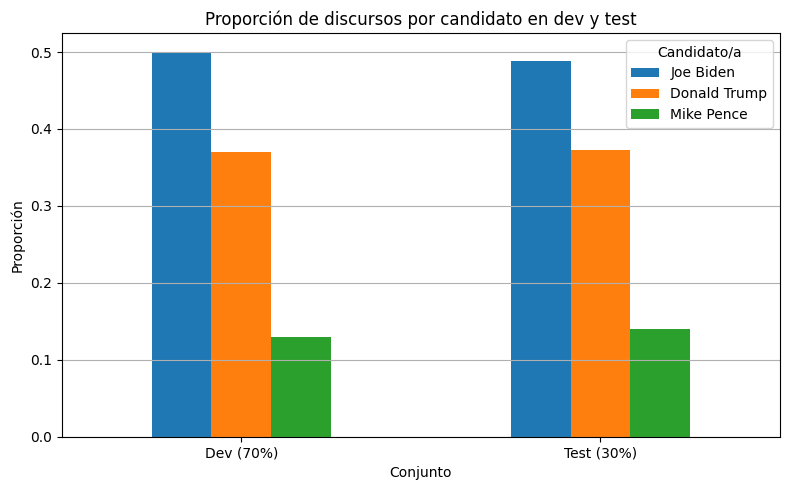

In [7]:
# 2: Visualización de la proporción de cada candidato por conjunto
import matplotlib.pyplot as plt

# Contar instancias por clase en cada conjunto
dev_counts = y_dev.value_counts(normalize=True)
test_counts = y_test.value_counts(normalize=True)

# Crear DataFrame combinado para graficar
proportion_df = pd.DataFrame({
    "Dev (70%)": dev_counts,
    "Test (30%)": test_counts
}).T

# Graficar
proportion_df.plot(kind="bar", figsize=(8, 5), rot=0)
plt.title("Proporción de discursos por candidato en dev y test")
plt.xlabel("Conjunto")
plt.ylabel("Proporción")
plt.legend(title="Candidato/a")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


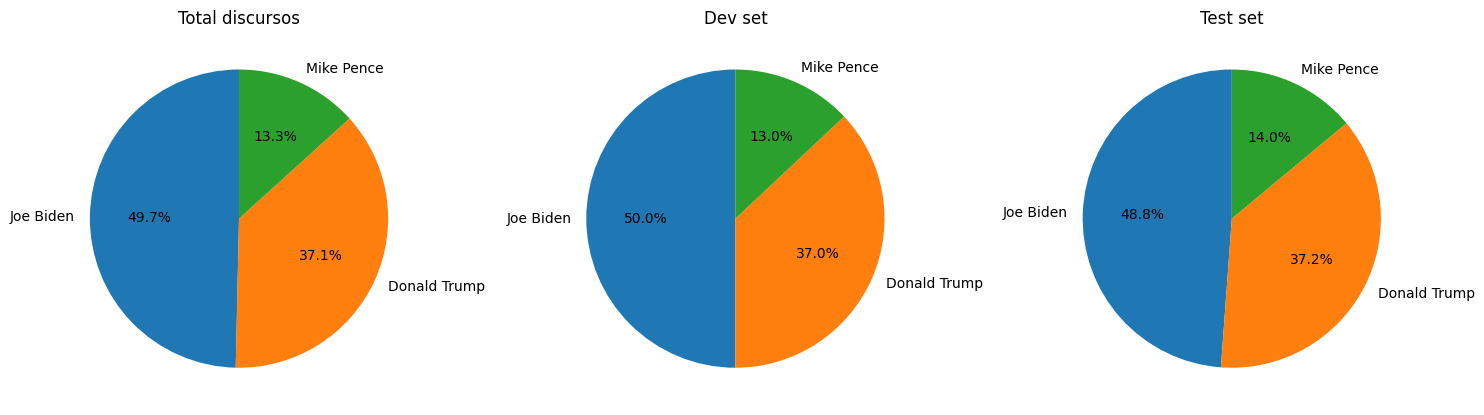

In [8]:
# Conteo total, train y test
total_counts = y.value_counts()
dev_counts = y_dev.value_counts()
test_counts = y_test.value_counts()

# Crear subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico total
axes[0].pie(total_counts, labels=total_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Total discursos')

# Gráfico dev
axes[1].pie(dev_counts, labels=dev_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Dev set')

# Gráfico test
axes[2].pie(test_counts, labels=test_counts.index, autopct='%1.1f%%', startangle=90)
axes[2].set_title('Test set')

plt.tight_layout()
plt.show()

In [21]:
# 3: Transforme el texto del conjunto de entrenamiento a la representación numérica (features) de conteo de palabras o bag of words.

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Inicializar vectorizador BoW
vectorizer = CountVectorizer()

# Ajustar al conjunto de desarrollo y transformar
X_dev_bow = vectorizer.fit_transform(X_dev)
X_test_bow = vectorizer.transform(X_test)

# Aplicar TF-IDF sobre la matriz BoW
tfidf = TfidfTransformer()
X_dev_tfidf = tfidf.fit_transform(X_dev_bow)
X_test_tfidf = tfidf.transform(X_test_bow)

# Mostrar dimensiones de las matrices
print(f"BoW shape (dev): {X_dev_bow.shape}")
print(f"TF-IDF shape (dev): {X_dev_tfidf.shape}")

print(f"\nNúmero total de palabras únicas: {len(vectorizer.get_feature_names_out())}")

# ----------------------------
# 4. Analizar la sparsidad
# ----------------------------
# Porcentaje de celdas con datos (densidad)
nnz = X_dev_bow.nnz  # cantidad de valores no cero
total = X_dev_bow.shape[0] * X_dev_bow.shape[1]
densidad = nnz / total * 100

print(f"Densidad matriz BoW (dev): {densidad:.4f}%")

# ----------------------------
# 5. Visualizar un ejemplo (opcional, solo para pocos textos)
# ----------------------------
# Mostrar las primeras 2 filas de la matriz BoW con nombres de palabras
vocab = vectorizer.get_feature_names_out()
ejemplo = X_dev_bow[:2].toarray()

df_ejemplo = pd.DataFrame(ejemplo, columns=vocab)
# Mostramos solo columnas con algún valor
print("Primeros discursos como BoW:")
print(df_ejemplo.loc[:, (df_ejemplo != 0).any(axis=0)])

BoW shape (dev): (100, 13669)
TF-IDF shape (dev): (100, 13669)

Número total de palabras únicas: 13669
Densidad matriz BoW (dev): 9.0451%
Primeros discursos como BoW:
   00  000  01  02  03  04  05  06  07  08  ...  yes  yet  yoga  york  you  \
0   0    0   1   1   1   1   1   2   0   0  ...    0    0     0     0   21   
1  15   14  66   4   8  10   7   5   5  10  ...    4    1     2    10  345   

   young  your  yourself  youth  zero  
0      0     2         0      0     0  
1      1    68         1      1     1  

[2 rows x 1984 columns]


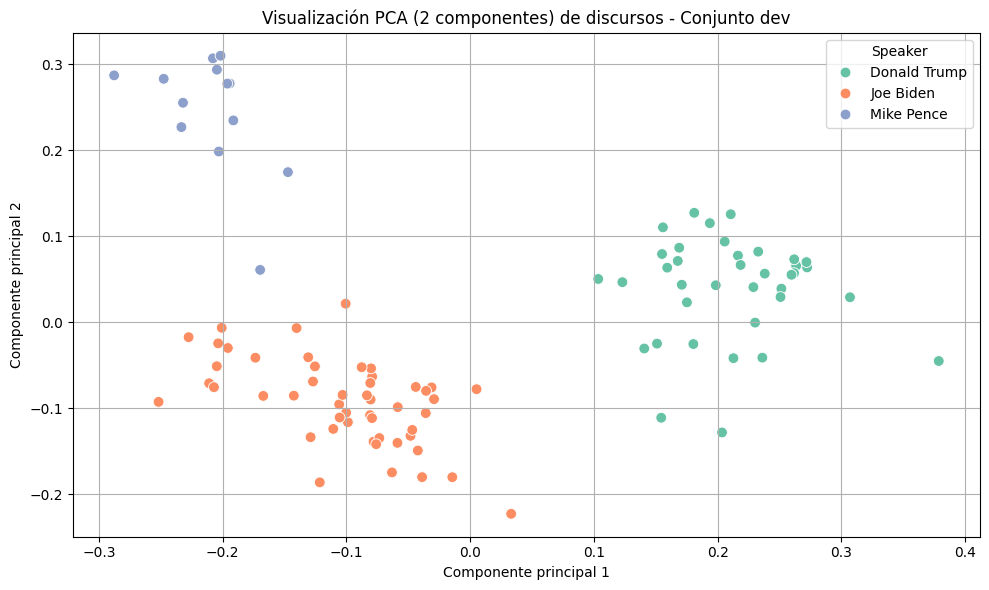

In [22]:
# 4: Obtenga la representación numérica Term Frequency - Inverse Document Frequency.


from sklearn.decomposition import PCA

# Reducir a 2 dimensiones usando PCA
pca = PCA(n_components=2)
X_dev_pca = pca.fit_transform(X_dev_tfidf.toarray())

# Crear DataFrame para graficar
pca_df = pd.DataFrame({
    'PCA1': X_dev_pca[:, 0],
    'PCA2': X_dev_pca[:, 1],
    'Speaker': y_dev.values
})

# Visualización
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Speaker', palette='Set2', s=60)
plt.title('Visualización PCA (2 componentes) de discursos - Conjunto dev')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.grid(True)
plt.tight_layout()
plt.show()


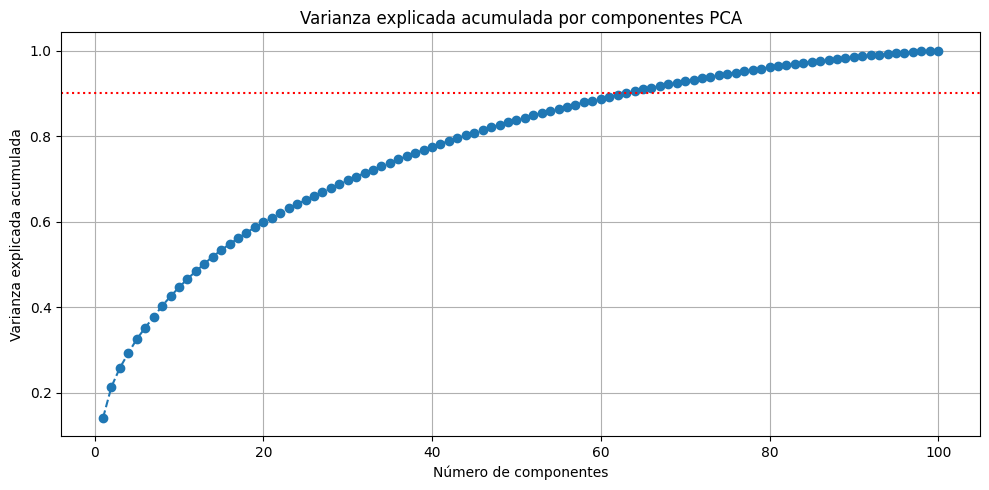

In [23]:
# 5 :Muestre en un mapa el conjunto de entrenamiento, utilizando las dos primeras componentes PCA sobre los vectores de tf-idf.


# Haga una visualización que permita entender cómo varía la varianza explicada a medida que se agregan componentes (e.g: hasta 10 componentes).


# PCA con más componentes para ver curva de varianza
pca_full = PCA()
pca_full.fit(X_dev_tfidf.toarray())

# Calcular varianza explicada acumulada
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Visualización
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='red', linestyle=':')  # Línea de referencia 90%
plt.title('Varianza explicada acumulada por componentes PCA')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.tight_layout()
plt.show()


## Parte 2: Entrenamiento y Evaluación de Modelos


C:\Users\juanp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.488
Precision (macro): 0.163
Recall (macro): 0.333


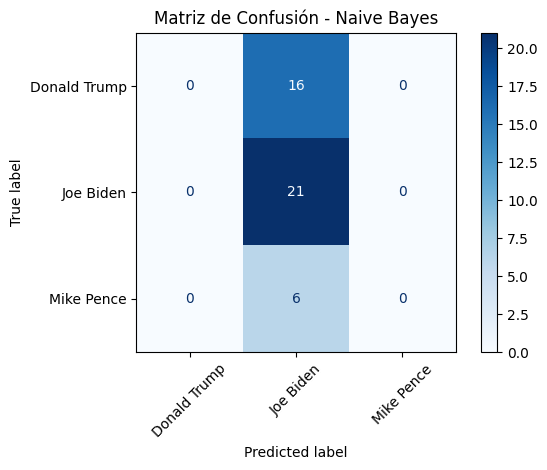

In [11]:
# 1: Entrene el modelo Multinomial Naive Bayes, luego utilícelo para predecir sobre el conjunto de test, y reporte el valor de accuracy y la matriz de confusión. Reporte el valor de precision y recall para cada candidato. 
# Calcular matriz de confusión Sugerencia: utilice el método from_predictions de ConfusionMatrixDisplay para realizar la matriz.


from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# Entrenar modelo con TF-IDF del conjunto de desarrollo
nb_model = MultinomialNB()
nb_model.fit(X_dev_tfidf, y_dev)

# Predecir sobre el conjunto de prueba
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluar métricas
accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb, average='macro')
recall = recall_score(y_test, y_pred_nb, average='macro')

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision (macro): {precision:.3f}")
print(f"Recall (macro): {recall:.3f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_nb, labels=nb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Matriz de Confusión - Naive Bayes')
plt.tight_layout()
plt.show()


Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\juanp\AppData\Local\Temp\ipykernel_25128\4046171661.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='param_alpha', y='mean_test_score', data=results_df, inner="quart", palette="muted")


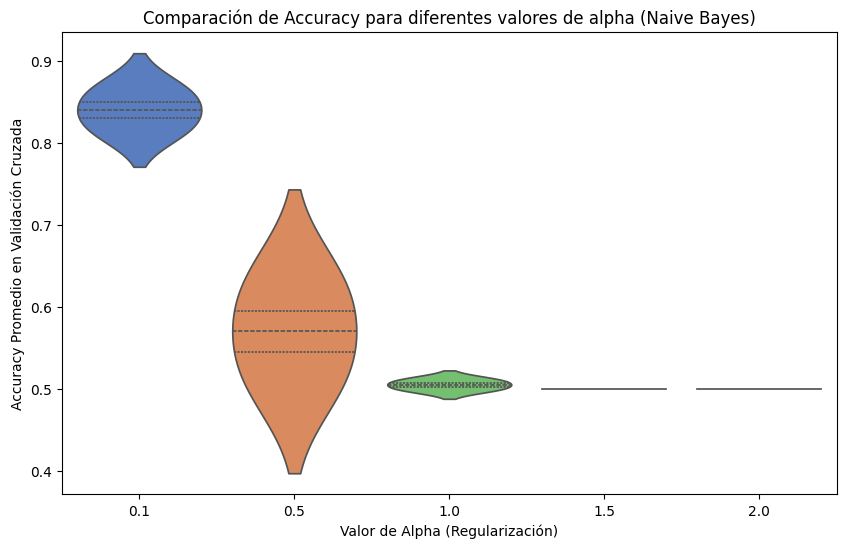

Mejores parámetros encontrados: {'alpha': 0.1, 'fit_prior': False}
Mejor Accuracy: 0.8600


In [26]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
# 1. Definir el modelo de Naive Bayes
nb_model = MultinomialNB()

# 2. Definir los parámetros a explorar en la búsqueda de hiperparámetros
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 1.5, 2.0],  # Regularización
    'fit_prior': [True, False]           # Si se debe ajustar la probabilidad previa
}

# 3. Crear el objeto GridSearchCV
grid_search = GridSearchCV(
    estimator=nb_model, 
    param_grid=param_grid, 
    cv=StratifiedKFold(n_splits=5),  # Utilizando 5 particiones (folds)
    scoring='accuracy',  # Métrica de evaluación
    return_train_score=True,  # Para obtener también el rendimiento en entrenamiento
    verbose=1
)

# 4. Ajustar el modelo con los datos de entrenamiento
grid_search.fit(X_dev_tfidf, y_dev)

# 5. Obtener los resultados del GridSearchCV
results = grid_search.cv_results_

# 6. Visualización: Comparación de accuracy entre los diferentes modelos

# Usamos seaborn para hacer un gráfico de violín
results_df = pd.DataFrame(results)

# Gráfico de violín de la métrica de accuracy (en todos los splits)
plt.figure(figsize=(10, 6))
sns.violinplot(x='param_alpha', y='mean_test_score', data=results_df, inner="quart", palette="muted")

plt.title('Comparación de Accuracy para diferentes valores de alpha (Naive Bayes)')
plt.xlabel('Valor de Alpha (Regularización)')
plt.ylabel('Accuracy Promedio en Validación Cruzada')
plt.show()

# 7. Reporte de los mejores parámetros y resultados
print("Mejores parámetros encontrados:", grid_search.best_params_)
print(f"Mejor Accuracy: {grid_search.best_score_:.4f}")

C:\Users\juanp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.837
Precision (macro): 0.583
Recall (macro): 0.646


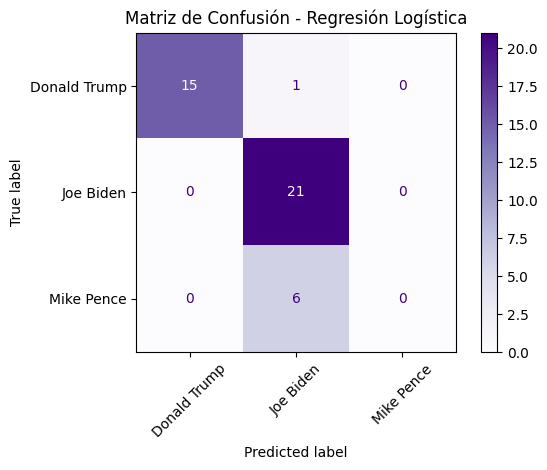

In [12]:
# 2: Implemente una búsqueda de hiperparámetros usando GridSearchCV.

# Genere una visualización que permita comparar las métricas (e.g: accuracy) de los distintos modelos entrenados, viendo el valor promedio y variabilidad de las mismas en todos los splits (e.g: en un gráfico de violín).


from sklearn.linear_model import LogisticRegression

# Entrenar modelo de regresión logística
log_model = LogisticRegression(solver='liblinear', random_state=42)
log_model.fit(X_dev_tfidf, y_dev)

# Predecir sobre test
y_pred_log = log_model.predict(X_test_tfidf)

# Evaluar métricas
accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log, average='macro')
recall = recall_score(y_test, y_pred_log, average='macro')

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision (macro): {precision:.3f}")
print(f"Recall (macro): {recall:.3f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_log, labels=log_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_model.classes_)
disp.plot(cmap='Purples', xticks_rotation=45)
plt.title('Matriz de Confusión - Regresión Logística')
plt.tight_layout()
plt.show()


In [13]:
# 3: Elija el mejor modelo (mejores parámetros) y vuelva a entrenar sobre todo el conjunto de entrenamiento disponible (sin quitar datos para validación). Reporte el valor final de las métricas y la matriz de confusión.


from sklearn.model_selection import GridSearchCV

# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # compatible con l1 y l2
}

# Configurar búsqueda con validación cruzada
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Ajustar al conjunto de desarrollo
grid_search.fit(X_dev_tfidf, y_dev)

# Mostrar los mejores parámetros y su desempeño
print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"Mejor accuracy en validación cruzada: {grid_search.best_score_:.3f}")


Mejores hiperparámetros: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor accuracy en validación cruzada: 0.990


Evaluación del mejor modelo en conjunto de prueba:
Accuracy: 1.000
Precision (macro): 1.000
Recall (macro): 1.000


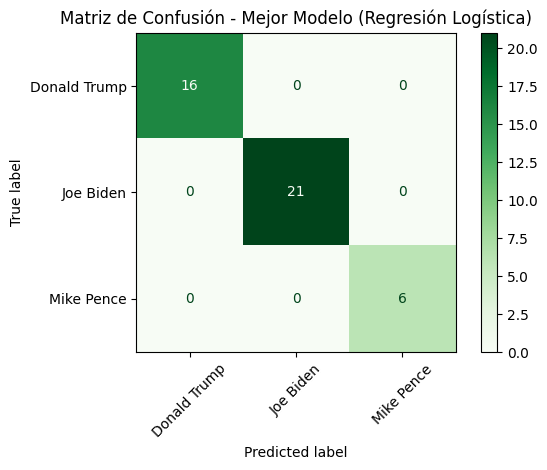

In [14]:
# 4: Evalúe con validación cruzada al menos un modelo más (dentro de scikit-learn) aparte de Multinomial Naive Bayes para clasificar el texto utilizando las mismas features de texto.


# Predecir sobre el conjunto de prueba con el mejor estimador
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_tfidf)

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='macro')
recall = recall_score(y_test, y_pred_best, average='macro')

print("Evaluación del mejor modelo en conjunto de prueba:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision (macro): {precision:.3f}")
print(f"Recall (macro): {recall:.3f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Greens', xticks_rotation=45)
plt.title('Matriz de Confusión - Mejor Modelo (Regresión Logística)')
plt.tight_layout()
plt.show()


In [15]:
# 5: Evalúe el problema cambiando al menos un candidato. En particular, observe el (des)balance de datos y los problemas que pueda generar, así como cualquier indicio que pueda ver en el mapeo previo con PCA.



# Obtener los 4 candidatos con más discursos
top_4 = df_speeches_clean["speaker"].value_counts().head(4).index.tolist()

# Reemplazar el tercero por el cuarto
candidatos_modificados = [top_4[0], top_4[1], top_4[3]]  # Ejemplo: [Trump, Biden, Bernie Sanders]
print("Candidatos seleccionados (con reemplazo):", candidatos_modificados)

# Filtrar dataset con estos 3 candidatos
df_alt = df_speeches_clean[df_speeches_clean["speaker"].isin(candidatos_modificados)]

# Variables predictoras y etiquetas
X_alt = df_alt["CleanText"]
y_alt = df_alt["speaker"]

# División dev/test (70/30) con estratificación
X_dev_alt, X_test_alt, y_dev_alt, y_test_alt = train_test_split(
    X_alt, y_alt, test_size=0.3, random_state=42, stratify=y_alt
)

# Mostrar distribución de clases
print("Distribución en conjunto de desarrollo (dev):")
print(y_dev_alt.value_counts())
print("\nDistribución en conjunto de prueba (test):")
print(y_test_alt.value_counts())

Candidatos seleccionados (con reemplazo): ['Joe Biden', 'Donald Trump', 'Bernie Sanders']
Distribución en conjunto de desarrollo (dev):
speaker
Joe Biden         50
Donald Trump      37
Bernie Sanders    11
Name: count, dtype: int64

Distribución en conjunto de prueba (test):
speaker
Joe Biden         21
Donald Trump      16
Bernie Sanders     5
Name: count, dtype: int64


In [29]:
# OPCIONAL: Repetir la clasificación con los tres candidatos con más discursos, pero esta vez clasificando a nivel de párrafos y no de discursos enteros.
# Crear una lista vacía para almacenar los párrafos y las etiquetas correspondientes
paragraphs = []
labels = []

# Iterar sobre cada discurso de cada candidato
for idx, row in df_speeches_top_3.iterrows():
    # Dividir el discurso en párrafos utilizando el salto de línea '\n'
    paragraphs_in_speech = row['CleanText'].split('\n')
    
    # Agregar cada párrafo y la etiqueta (candidato) a las listas
    for paragraph in paragraphs_in_speech:
        if paragraph.strip():  # Asegurarnos de que no estamos agregando párrafos vacíos
            paragraphs.append(paragraph)
            labels.append(row['speaker'])  # Asumimos que la columna 'speaker' tiene el nombre del candidato

# Crear un nuevo DataFrame con los párrafos y sus etiquetas
df_paragraphs = pd.DataFrame({'text': paragraphs, 'label': labels})

# Paso 2: Revisar los primeros párrafos para asegurarnos de que la división fue exitosa
print(df_paragraphs.head())

                                                text         label
0  hello michigan hi how are you what’s your name...     Joe Biden
1  thank you what a nice group thank you very muc...  Donald Trump
2  hey and welcome to our town hall with joe bide...     Joe Biden
3  it’s nothing but noise what okay all right lad...  Donald Trump
4  thank you very much thank you let’s see it’s 1...  Donald Trump


Accuracy: 0.8604651162790697

Classification Report:
               precision    recall  f1-score   support

Donald Trump       0.94      1.00      0.97        16
   Joe Biden       0.81      1.00      0.89        21
  Mike Pence       0.00      0.00      0.00         6

    accuracy                           0.86        43
   macro avg       0.58      0.67      0.62        43
weighted avg       0.74      0.86      0.80        43



C:\Users\juanp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\juanp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\juanp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:

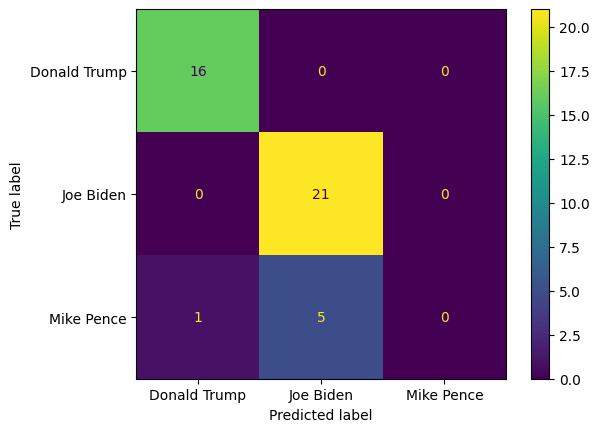

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Dividir el conjunto de datos en train y test
X = df_paragraphs['text']
y = df_paragraphs['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Aplicar TF-IDF al conjunto de entrenamiento
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,2))  # Se puede ajustar el n-grama aquí
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Paso 4: Entrenar el modelo (por ejemplo, Naive Bayes)
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

# Entrenar el modelo
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Paso 5: Evaluar el modelo
y_pred = model.predict(X_test_tfidf)

# Reporte de las métricas
print("Accuracy:", model.score(X_test_tfidf, y_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay

conf_matrix = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(conf_matrix, display_labels=model.classes_).plot()